<a href="https://colab.research.google.com/github/vicmanso/meu-arquivo-csv/blob/main/Projeto_Final_%7C_Bases_Computacionais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aylla Johann Dias Freitas RA 11202421212

Victoria de Brito Manso RA 11202421213

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Criação da base de dados

Para criação da base de dados, selecionamos atores, cantores e jogadores de vôlei de diferentes nacionalidades e gêneros para uma visão diversa dos grupos.

Arquivo CSV https://raw.githubusercontent.com/vicmanso/meu-arquivo-csv/main/personalidades.csv


In [ ]:
personalidades=pd.read_csv('https://raw.githubusercontent.com/vicmanso/meu-arquivo-csv/main/personalidades.csv')
personalidades

,Nome,Data de nascimento,Altura,Nacionalidade,Gênero,Grupo
0,Antonio Bandeiras,10/08/1960,1.74,Espanhol,Masculino,Atores
1,Armaan Malik,22/07/1995,1.70,Indiano,Masculino,Cantores
2,Avril Lavigne,27/09/1984,1.65,Canadense,Feminino,Cantores
3,Bartosz Kurek,29/08/1988,2.05,Polonês,Masculino,Jogadores de Vôlei
4,Beyonce,04/09/1981,1.68,Estadunidense,Feminino,Cantores
5,Camila Morgado,12/04/1975,1.69,Brasileira,Feminino,Atores
6,Adele,05/05/1988,1.76,Britânica,Feminino,Cantores
7,Enrique Iglesias,08/05/1975,1.87,Espanhol,Masculino,Cantores
8,Freddie Mercury,05/09/1946,1.77,Tanzaniano,Masculino,Cantores
9,György Grozer,27/11/1984,2.01,Alemão,Masculino,Jogadores de Vôlei


# Análise de fatores específicos

1. **Uso de funções 'min' e 'max' na descoberta de fatores específicos**

- Para identificar *o gupo da pessoa mais velha, o nome da pessoa mais nova, a nacionalidade da pessoa mais alta e o gênero da pessoa mais baixa*, foi utilizado a função "min" e "max".

> Poder identificar esses fatores específicos e suas relações entre as categorias expostas é de suma importância para uma análise geral dos dados e suas propriedades marcantes.



In [ ]:
# Criar uma coluna com o Ano das Datas de nascimento
personalidades['Ano']=pd.to_datetime(personalidades['Data de nascimento'],format='%d/%m/%Y').dt.year

# Encontrar a idade máxima
idade_máxima = personalidades['Ano'].min()

# Encontrar a pessoa com a idade máxima
pessoa_mais_velha = personalidades[personalidades['Ano'] == idade_máxima]

print(f"O grupo da pessoa mais velha é {pessoa_mais_velha['Grupo'].values[0]} e seu ano de nascimento é {idade_máxima}.")

# Encontrar a idade mínima
idade_mínima = personalidades['Ano'].max()

# Encontrar a pessoa com a idade mínima
pessoa_mais_nova = personalidades[personalidades['Ano'] == idade_mínima]

print(f"O nome da pessoa mais nova é {pessoa_mais_nova['Nome'].values[0]} e seu ano de nascimento é {idade_mínima}.")


# Encontrar a altura máxima
altura_máxima = personalidades['Altura'].max()

# Encontrar a pessoa com a altura máxima
pessoa_mais_baixa = personalidades[personalidades['Altura'] == altura_máxima]

print(f"A nacionalidade da pessoa mais alta é {pessoa_mais_baixa['Nacionalidade'].values[0]} e sua altura é {altura_máxima} metros.")

#Encontrar a altura mínima
altura_minima = personalidades['Altura'].min()

# Encontrar a pessoa com a altura mínima
pessoa_mais_baixa = personalidades[personalidades['Altura'] == altura_minima]

print(f"O gênero da pessoa mais baixa é {pessoa_mais_baixa['Gênero'].values[0]} e sua altura é {altura_minima} metros.")

O grupo da pessoa mais velha é Atores e seu ano de nascimento é 1931.
O nome da pessoa mais nova é Tyla e seu ano de nascimento é 2002.
A nacionalidade da pessoa mais alta é Polonês e sua altura é 2.05 metros.
O gênero da pessoa mais baixa é Feminino e sua altura é 1.57 metros.


# Inclusão de coluna utilizando os dados já expressos na tabela

2. **Criação de coluna através de manipulação de dados**

- Nessa etapa, criamos a coluna "Idade", que corresponde à relação entre o ano de nascimento e o ano em que estamos hoje.
 > Essa manipulação de dados é necessária na análise da relação entre as categorias expressas; e a criação de novas colunas é um modo prático de se obter uma melhor visualização de um dado específico.

In [ ]:
personalidades['Idade'] = 2024 - personalidades['Ano']
personalidades

,Nome,Data de nascimento,Altura,Nacionalidade,Gênero,Grupo,Ano,Idade
0,Antonio Bandeiras,10/08/1960,1.74,Espanhol,Masculino,Atores,1960,64
1,Armaan Malik,22/07/1995,1.70,Indiano,Masculino,Cantores,1995,29
2,Avril Lavigne,27/09/1984,1.65,Canadense,Feminino,Cantores,1984,40
3,Bartosz Kurek,29/08/1988,2.05,Polonês,Masculino,Jogadores de Vôlei,1988,36
4,Beyonce,04/09/1981,1.68,Estadunidense,Feminino,Cantores,1981,43
5,Camila Morgado,12/04/1975,1.69,Brasileira,Feminino,Atores,1975,49
6,Adele,05/05/1988,1.76,Britânica,Feminino,Cantores,1988,36
7,Enrique Iglesias,08/05/1975,1.87,Espanhol,Masculino,Cantores,1975,49
8,Freddie Mercury,05/09/1946,1.77,Tanzaniano,Masculino,Cantores,1946,78
9,György Grozer,27/11/1984,2.01,Alemão,Masculino,Jogadores de Vôlei,1984,40


# Ranqueamento por valores númericos

3. **Classificar em ordem do mais alto ao mais baixo dentre as personalidades, utilizando a função rank e sort_values:**
> Poder ranquear os valores de uma base de dados é fundamental para uma melhor visualização dos dados, sempre que se busca analisar um critério específico, como neste caso a altura.

In [ ]:
# Criar uma nova coluna para classificação com base na altura
personalidades['Classificação'] = personalidades['Altura'].rank(ascending=False, method='min') # method='min' atribui o menor valor em caso de empate

# Colocar a classificação em ordem (do 1º ao 30º)
personalidades.sort_values(['Classificação'])

,Nome,Data de nascimento,Altura,Nacionalidade,Gênero,Grupo,Ano,Idade,Classificação
3,Bartosz Kurek,29/08/1988,2.05,Polonês,Masculino,Jogadores de Vôlei,1988,36,1.0
9,György Grozer,27/11/1984,2.01,Alemão,Masculino,Jogadores de Vôlei,1984,40,2.0
29,Zhu Ting,29/11/1994,1.98,Chinesa,Feminino,Jogadores de Vôlei,1994,30,3.0
10,Isabelle Haak,11/07/1999,1.94,Sueca,Feminino,Jogadores de Vôlei,1999,25,4.0
14,Luciano De Cecco,02/06/1998,1.94,Argentino,Masculino,Jogadores de Vôlei,1998,26,4.0
17,Melissa Vargas,16/10/1999,1.93,Cubana,Feminino,Jogadores de Vôlei,1999,25,6.0
19,Paola Egonu,18/12/1998,1.93,Italiana,Feminino,Jogadores de Vôlei,1998,26,6.0
11,Jenia Grebennikov,13/08/1990,1.88,Francês,Masculino,Jogadores de Vôlei,1990,34,8.0
7,Enrique Iglesias,08/05/1975,1.87,Espanhol,Masculino,Cantores,1975,49,9.0
28,Yuji Nishida,30/01/2000,1.86,Japonês,Masculino,Jogadores de Vôlei,2000,24,10.0


# Histograma da altura das personalidades

4. Para visualizar a distribuição das alturas das personalidades, o histograma é ideal.
> Este métdodo de demonstração dos dados é um excelente representativo da frequência que uma categoria pode ter, particularmente por seu teor visual que auxilia uma melhor compreensão de como tal informação está distribuída entre os componentes da base de dados.

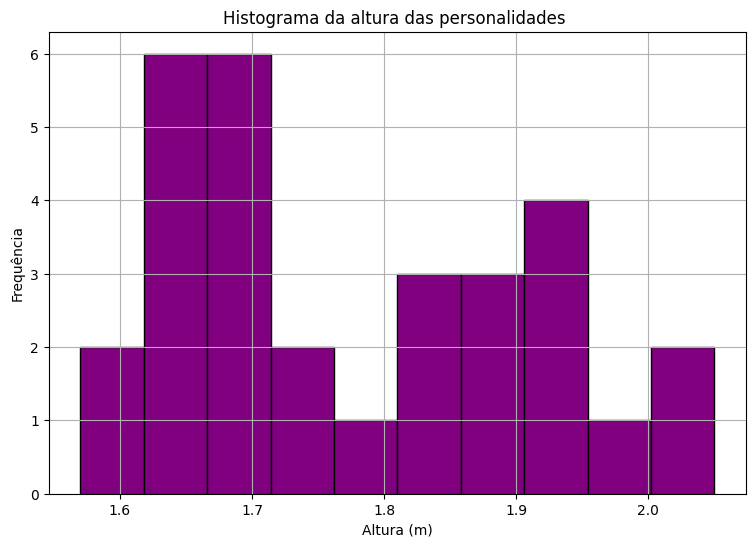

In [ ]:
# Criar um histograma das alturas
plt.figure(figsize=(9,6))
plt.hist(personalidades['Altura'], bins=10, ec="k", color='purple') #bins=10 define os intervalos de altura
plt.title('Histograma da altura das personalidades ')
plt.xlabel('Altura (m)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# Inclusão de coluna com dados externos

5. Adição de coluna relativa ao patrimônio líquido das personalidades na base de dados, através de valores externos.
- Para realizar essa adição, primeiro define a lista dos valores com um nome -- neste caso, como 'Patrimônio_líquido_em_milhões_de_reais" --  na ordem em que estão dispostois as personalidades na tabela original, e depois é incluída a nova coluna como no exemplo 2.
> Essa manipulação da base de dados, com inclusão de valores externos se demonstra extremamente útil e prático para alteração da tabela após novas coletas de informações.

In [ ]:
# Definindo a lista
Patrimônio_líquido_em_milhões_de_reais =[241, 133, 335, 5.6, 3023, 10, 1232, 560, 280, 4.87, 27.99, 5.8, 139.96, 26, 5.2, 104, 156, 5.2, 208, 5.2, 624, 26, 130, 5.2, 364, 1040, 2.6, 130, 5.2, 5.2 ]
# Incluindo a coluna com os valores definidos da lista
personalidades['Patrimônio líquido em milhões de reais'] = Patrimônio_líquido_em_milhões_de_reais
personalidades

,Nome,Data de nascimento,Altura,Nacionalidade,Gênero,Grupo,Ano,Idade,Classificação,Patrimônio líquido em milhões de reais
0,Antonio Bandeiras,10/08/1960,1.74,Espanhol,Masculino,Atores,1960,64,16.0,241.00
1,Armaan Malik,22/07/1995,1.70,Indiano,Masculino,Cantores,1995,29,17.0,133.00
2,Avril Lavigne,27/09/1984,1.65,Canadense,Feminino,Cantores,1984,40,23.0,335.00
3,Bartosz Kurek,29/08/1988,2.05,Polonês,Masculino,Jogadores de Vôlei,1988,36,1.0,5.60
4,Beyonce,04/09/1981,1.68,Estadunidense,Feminino,Cantores,1981,43,21.0,3023.00
5,Camila Morgado,12/04/1975,1.69,Brasileira,Feminino,Atores,1975,49,20.0,10.00
6,Adele,05/05/1988,1.76,Britânica,Feminino,Cantores,1988,36,15.0,1232.00
7,Enrique Iglesias,08/05/1975,1.87,Espanhol,Masculino,Cantores,1975,49,9.0,560.00
8,Freddie Mercury,05/09/1946,1.77,Tanzaniano,Masculino,Cantores,1946,78,14.0,280.00
9,György Grozer,27/11/1984,2.01,Alemão,Masculino,Jogadores de Vôlei,1984,40,2.0,4.87


- Correlação entre altura e patrimônio líquido das personalidades:


---
O resultado demonstrou **baixíssima correlação** entre os dois fatores, com coeficiente de correlação beirando a 0. Este resultado pode ser explicado por diversos fatores, como quantidade de personalidades analisadas ser insuficiente para um resultado notório, dado que essa correlação diz respeito unicamente ao grupo estudado, de 30 indíviduos e pode-se concluir apenas que, dentre os participantes, a correlação não é determinante; bem como pode representar de fato que não há correlação entre altura e patrimônio líquido.


Correlação entre as grandezas:  -0.20270616630149157
Comentários: o coeficiênte de correlação é negativo e muito próximo de 0, o que indica uma correlação baixa e quase nula entre os valores, de ordem decrescente


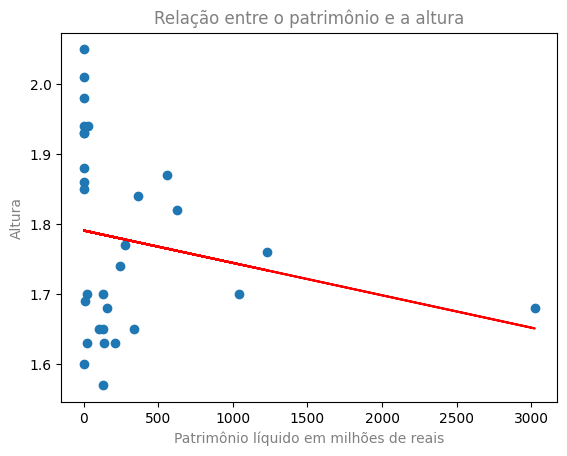

In [ ]:
m, b = np.polyfit(personalidades['Patrimônio líquido em milhões de reais'], personalidades['Altura'],
                  deg=1)
plt.plot(personalidades['Patrimônio líquido em milhões de reais'], personalidades['Altura'], marker='o', linestyle = '')
plt.plot(personalidades['Patrimônio líquido em milhões de reais'], m*personalidades['Patrimônio líquido em milhões de reais']+b,color='red')
plt.xlabel('Patrimônio líquido em milhões de reais', color = 'grey')
plt.ylabel('Altura', color = 'grey')
plt.title('Relação entre o patrimônio e a altura', color = 'grey')
print('Correlação entre as grandezas: ', personalidades['Patrimônio líquido em milhões de reais'].corr(personalidades['Altura']))
print('Comentários: o coeficiênte de correlação é negativo e muito próximo de 0, o que indica uma correlação baixa e quase nula entre os valores, de ordem decrescente')
plt.show()


# Retorno aleatório

6. Função que retorne uma personalidade aleatória ao se escolher um grupo.

In [ ]:
import random
# Função que retorna aleatoriamente um integrante de um grupo
def integrante_aleatorio(grupo):

 # Filtrar os integrantes do grupo informado
 integrantes_do_grupo = personalidades[personalidades['Grupo'] == grupo]['Nome']

 return random.choice(integrantes_do_grupo.values)

# Testar a função
grupo = input("Digite o nome de um grupo (Atores, Cantores, Jogadores de Vôlei): ")
resultado = integrante_aleatorio(grupo)
print(f"Integrante aleatório do grupo '{grupo}': {resultado}")

Digite o nome de um grupo (Atores, Cantores, Jogadores de Vôlei): Atores
Integrante aleatório do grupo 'Atores': Camila Morgado


# Análise descritiva e comparativa dos grupos

**7. Análise da relação entre gênero e patrimônio líquido de atores, com uso de histograma para melhor visualização das frequências relativas ao patrimônio de cada gênero**
- Foi utilizado a biblioteca matplotlib.pyplot para executar o histograma; assim como a função query para selecionar os gêneros e o grupo a ser analisado -- neste caso, de atores


---

O histograma permitiu visualizar que é mais **frequente** que mulheres tenham um patrimônio líquido menor que os homens estudados. Embora seja possível visualizar também que o patrimônio maior pertence a uma mulher.

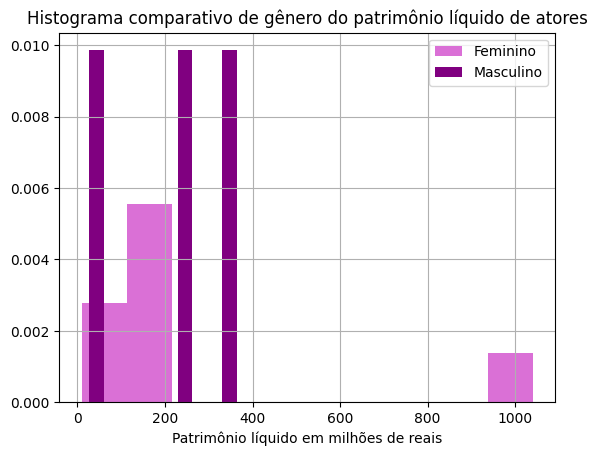

In [ ]:
# Execução do histograma e seleção (query) do gênero feminino e grupo de atores
plt.hist(personalidades.query("Gênero == 'Feminino'and Grupo == 'Atores'")['Patrimônio líquido em milhões de reais'], label = 'Feminino', color = 'orchid', density = True) # inclusão de legenda e cor
# Execução do histograma e seleção (query) do gênero masculino e grupo de atores
plt.hist(personalidades.query("Gênero == 'Masculino' and Grupo == 'Atores'")['Patrimônio líquido em milhões de reais'], label = 'Masculino', color = 'purple', density= True)
#Legenda do eixo x
plt.xlabel('Patrimônio líquido em milhões de reais')
#Inserção de legenda
plt.legend()
#Inserção de título
plt.title('Histograma comparativo de gênero do patrimônio líquido de atores')
# Inserção de grade
plt.grid()
plt.show()

- **Análise do patrimônio líquido médio por gênero a partir dos grupos**


---

A análise da média do patrimônio líquido dos gêneros permitiu observar que, no grupo estudado, as mulheres possuem um patrimônio médio siginificantivamente superior ao masculino

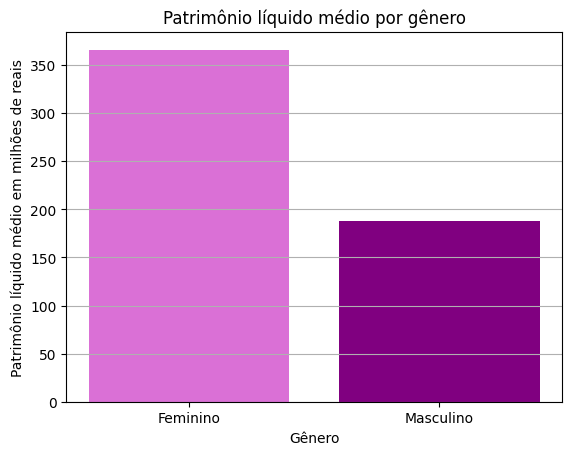

In [ ]:
#Cálculo da média
média = personalidades.groupby('Gênero')['Patrimônio líquido em milhões de reais'].mean()
#Execução do gráfico em barras utilizando os dados obtidos na média
plt.bar(média.index, média , color = ['orchid', 'purple'])
plt.title('Patrimônio líquido médio por gênero')
plt.xlabel('Gênero')
plt.ylabel('Patrimônio líquido médio em milhões de reais')
plt.grid(axis= 'y')
plt.show()

- Comparação entre o patrimônio dos diferentes grupos


---


A leitura do gráfico gerado permite visualizar que os jogadores de vôlei possuem um patrimônio substancialmente inferior em relação às demais categorias e que os cantores possuem o maior.



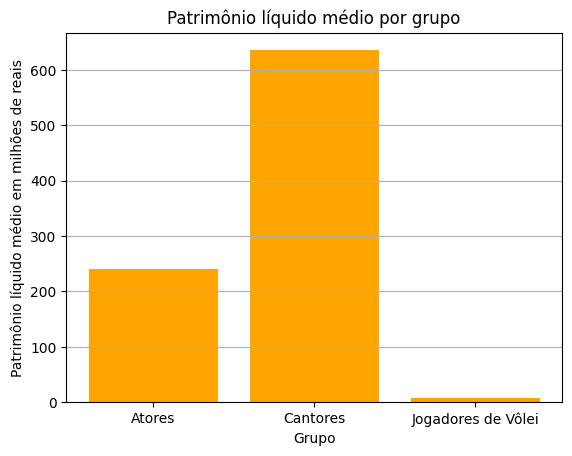

In [ ]:
# Calcula a média do patrimônio líquido por grupo
média_por_grupo = personalidades.groupby('Grupo')['Patrimônio líquido em milhões de reais'].mean()

# Plota o gráfico de barras
plt.bar(média_por_grupo.index, média_por_grupo, color='orange')

plt.title('Patrimônio líquido médio por grupo')
plt.xlabel('Grupo')
plt.ylabel('Patrimônio líquido médio em milhões de reais')
plt.grid(axis='y')  # Adiciona a grade somente no eixo y para melhor visualização
plt.show()

- Análise comparativa entre os grupos, de acordo com os gênero:


---

O gráfico permitiu notar que o patrimônio feminino é superior em todos os grupos e que há uma discrepância notória entre os grupos.

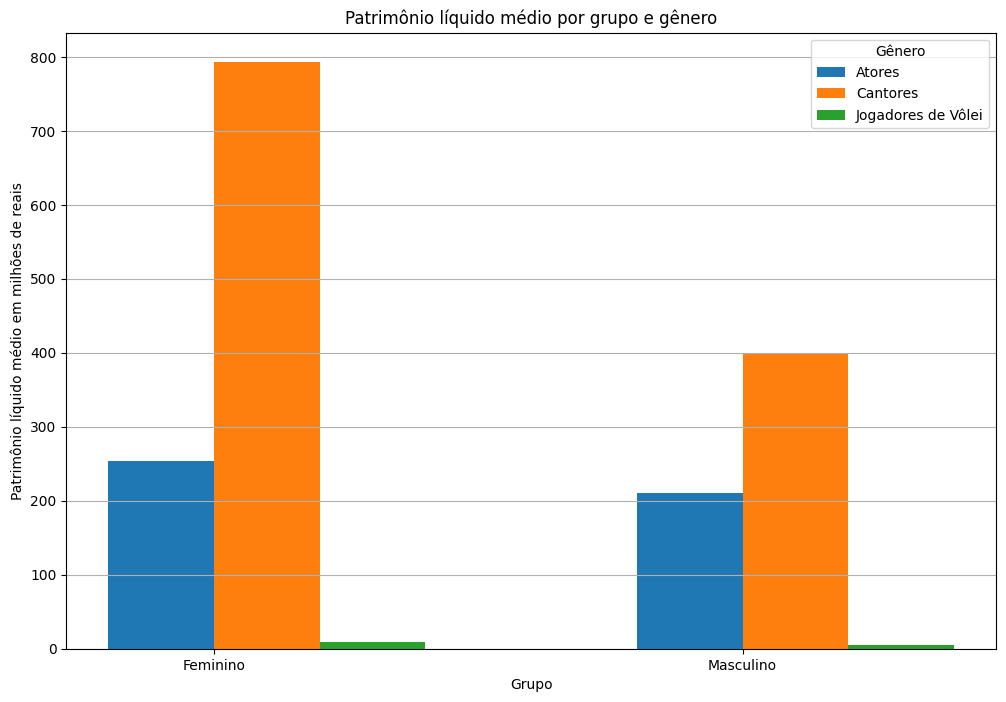

In [ ]:
# Calcula a média do patrimônio líquido por gênero e grupo
média_por_gênero_e_grupo = personalidades.groupby(['Gênero', 'Grupo'])['Patrimônio líquido em milhões de reais'].mean().unstack()

# Cria um gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 8))

# Define a largura das barras e a posição das barras
bar_width = 0.2
index = np.arange(len(média_por_gênero_e_grupo.index))

# Adiciona barras para cada gênero
for i, gênero in enumerate(média_por_gênero_e_grupo.columns):
    ax.bar(index + i * bar_width, média_por_gênero_e_grupo[gênero], bar_width, label=gênero)

# Configura o gráfico
ax.set_xlabel('Grupo')
ax.set_ylabel('Patrimônio líquido médio em milhões de reais')
ax.set_title('Patrimônio líquido médio por grupo e gênero')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(média_por_gênero_e_grupo.index)
ax.legend(title='Gênero')
ax.grid(axis='y')

plt.show()

# Medidas estatísticas

- Medidas estatísticas de cada grupo, utilizando dados de idade, altura e patrimônio para cálculo de suas médias, medianas e moda:


---

Os resultados permitiram uma visão mais ampla do dos grupos, podendo concluir informações como por exemplo, o grupo que tem uma média de pessoas mais novas é o de jogadores de vôlei.

In [ ]:
# Calculando a média, mediana e moda de idade, altura e patrimônio por grupo
grupos = personalidades['Grupo'].unique()
estatisticas = {}

# Iterando pelos grupos e calculando as estatísticas
for grupo in grupos:
    dados_grupo = personalidades[personalidades['Grupo'] == grupo]

    # Calculando a média
    media_idade = dados_grupo['Idade'].mean()
    media_altura = dados_grupo['Altura'].mean()
    media_patrimonio = dados_grupo['Patrimônio líquido em milhões de reais'].mean()

    # Calculando a mediana
    mediana_idade = dados_grupo['Idade'].median()
    mediana_altura = dados_grupo['Altura'].median()
    mediana_patrimonio = dados_grupo['Patrimônio líquido em milhões de reais'].median()

    # Calculando a moda e pegando o primeiro valor
    moda_idade = dados_grupo['Idade'].mode()[0]
    moda_altura = dados_grupo['Altura'].mode()[0]
    moda_patrimonio = dados_grupo['Patrimônio líquido em milhões de reais'].mode()[0]

    # Salvando as estatísticas no dicionário
    estatisticas[grupo] = {'Média de Idade': media_idade,
        'Mediana de Idade': mediana_idade,
        'Moda de Idade': moda_idade,
        'Média de Altura': media_altura,
        'Mediana de Altura': mediana_altura,
        'Moda de Altura': moda_altura,
        'Média de Patrimônio (milhões)': media_patrimonio,
        'Mediana de Patrimônio (milhões)': mediana_patrimonio,
        'Moda de Patrimônio (milhões)': moda_patrimonio}

# Imprimindo as estatísticas por grupo
for grupo, valores in estatisticas.items():
    print(f"Grupo: {grupo}")
    print(f"Média de Idade: {valores['Média de Idade']:.2f}")
    print(f"Mediana de Idade: {valores['Mediana de Idade']:.2f}")
    print(f"Moda de Idade: {valores['Moda de Idade']:.2f}")
    print(f"Média de Altura: {valores['Média de Altura']:.2f} m")
    print(f"Mediana de Altura: {valores['Mediana de Altura']:.2f} m")
    print(f"Moda de Altura: {valores['Moda de Altura']:.2f} m")
    print(f"Média de Patrimônio: {valores['Média de Patrimônio (milhões)']:.2f} milhões de reais")
    print(f"Mediana de Patrimônio: {valores['Mediana de Patrimônio (milhões)']:.2f} milhões de reais")
    print(f"Moda de Patrimônio: {valores['Moda de Patrimônio (milhões)']:.2f} milhões de reais")

Grupo: Atores
Média de Idade: 60.00
Mediana de Idade: 56.00
Moda de Idade: 34.00
Média de Altura: 1.68 m
Mediana de Altura: 1.67 m
Moda de Altura: 1.63 m
Média de Patrimônio: 240.90 milhões de reais
Mediana de Patrimônio: 143.00 milhões de reais
Moda de Patrimônio: 130.00 milhões de reais
Grupo: Cantores
Média de Idade: 45.50
Mediana de Idade: 41.50
Moda de Idade: 22.00
Média de Altura: 1.72 m
Mediana de Altura: 1.70 m
Moda de Altura: 1.70 m
Média de Patrimônio: 635.56 milhões de reais
Mediana de Patrimônio: 307.50 milhões de reais
Moda de Patrimônio: 2.60 milhões de reais
Grupo: Jogadores de Vôlei
Média de Idade: 29.60
Mediana de Idade: 28.00
Moda de Idade: 25.00
Média de Altura: 1.94 m
Mediana de Altura: 1.94 m
Moda de Altura: 1.93 m
Média de Patrimônio: 7.55 milhões de reais
Mediana de Patrimônio: 5.20 milhões de reais
Moda de Patrimônio: 5.20 milhões de reais


- Gráfico da idade média por gênero e grupo


---

A leitura do gráfico demonstra que as mulheres atrizes possuem a média da idade maior de todos os grupos analisados e que, em ambos os gêneros, o grupo mais velho é sempre composto de atores, e o mais novo de jogadores de vôlei

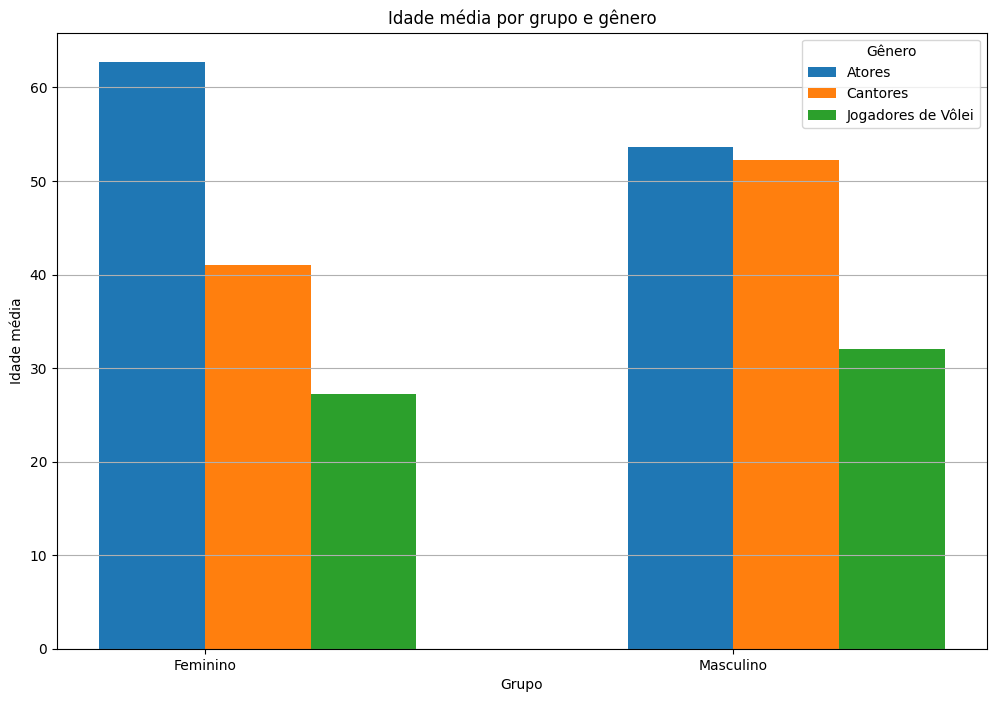

In [ ]:
# Calcula a média da idade por gênero e grupo
média_idade_gênero_e_grupo = personalidades.groupby(['Gênero', 'Grupo'])['Idade'].mean().unstack()
# Cria um gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 8))

# Define a largura das barras e a posição das barras
bar_width = 0.2
index = np.arange(len(média_idade_gênero_e_grupo.index))

# Adiciona barras para cada gênero
for i, gênero in enumerate(média_idade_gênero_e_grupo.columns):
    ax.bar(index + i * bar_width, média_idade_gênero_e_grupo[gênero], bar_width, label=gênero)

# Configura o gráfico
ax.set_xlabel('Grupo')
ax.set_ylabel('Idade média')
ax.set_title('Idade média por grupo e gênero')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(média_idade_gênero_e_grupo.index)
ax.legend(title='Gênero')
ax.grid(axis='y')

plt.show()

- Gráfico em barras da altura média por gênero e grupo


---

A partir do gráfico gerado, é clara a relação entre os grupos e as altuas, em que o grupo com altura maior em ambos os gêneros é o de jogadores de vôlei, e mais baixo o grupo de atores.

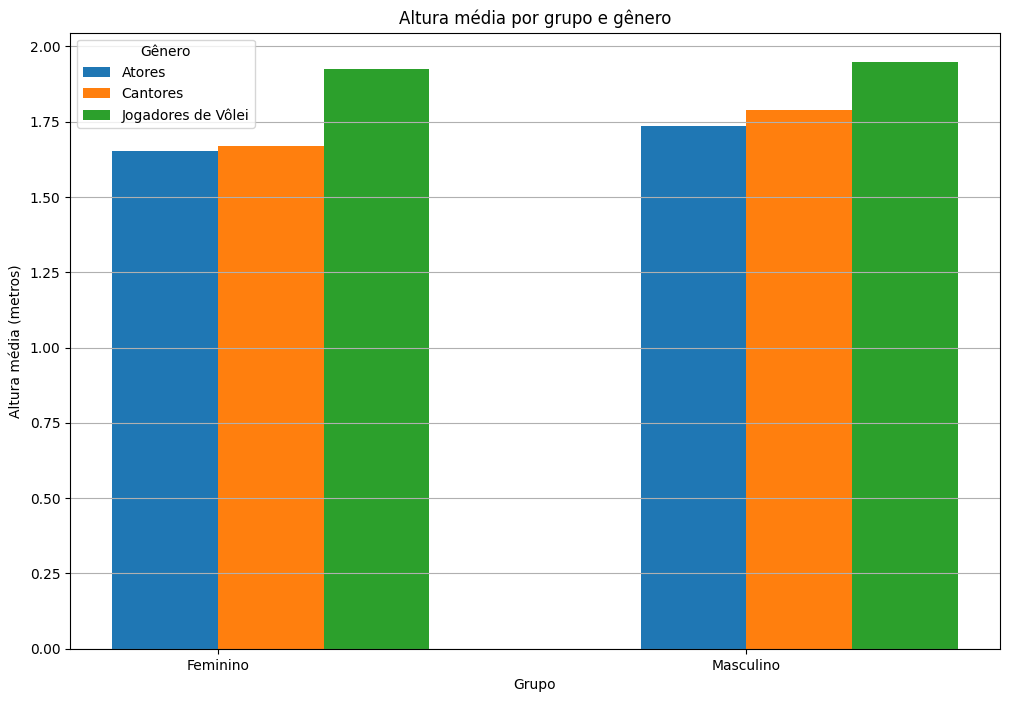

In [ ]:
# Calcula a média da altura por gênero e grupo
média_altura_gênero_e_grupo = personalidades.groupby(['Gênero', 'Grupo'])['Altura'].mean().unstack()
# Cria um gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 8))

# Define a largura das barras e a posição das barras
bar_width = 0.2
index = np.arange(len(média_altura_gênero_e_grupo.index))

# Adiciona barras para cada gênero
for i, gênero in enumerate(média_altura_gênero_e_grupo.columns):
    ax.bar(index + i * bar_width, média_altura_gênero_e_grupo[gênero], bar_width, label=gênero)

# Configura o gráfico
ax.set_xlabel('Grupo')
ax.set_ylabel('Altura média (metros)')
ax.set_title('Altura média por grupo e gênero')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(média_idade_gênero_e_grupo.index)
ax.legend(title='Gênero')
ax.grid(axis='y')

plt.show()

# Conclusão

O presente relatório possibilitou uma análise ampla das personalidades e suas características pessoais e coletivas.

Foi possível observar a relação entre **gênero** e **patrimônio líquido**, com a conclusão de que as mulheres analisadas detêm um capital médio superior ao masculino, por mais que frequentemente recebam menos -- o que demosntra também uma desigualdade dentre as personalidades femininas, na qual a que possui um patrimônio menor equivale a 5.2 milhões de reais, enquanto a com o patrimônio maior possui o equivalente a 3 bilhões de reais (cerca de 577 vezes mais).

Pode-se observar, também, que não há correlação entre altura e Patrimônio líquido entre as personalidades analisadas, o que contraria os resultados obtidos na pesquisa feita pelos IBMEC-SP e Universidade de São Paulo, em 2008 [1], na qual a análise acerca da relação entre altura e salário se demonstrou notória, em que pessoas mais altas, em especial homens, tendiam a ter uma renda superior em comparação àqueles de altura inferior, como demonstra o gráfico expresso no artigo [1]:
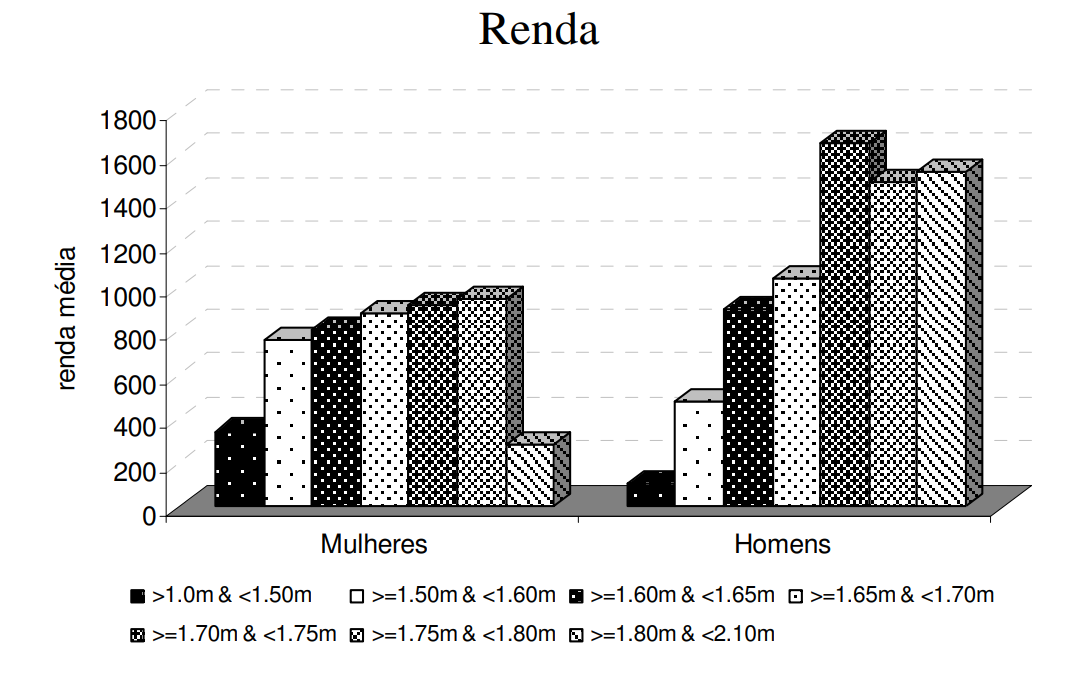
Os motivos pelos quais os resultados são distintos se deve a dois fatores principais, o primeiro é de que o grupo que selecionamos inclui apenas pessoas famosas, limitado a três profissões; e o segundo se deve à quantidade significativamente inferior de dados de entrada (30 pessoas), enquanto a pesquisa conduzida pela USP engloba diversas profissões, com dados coletados pelo IBGE acerca da população brasileira no geral.

Diante do exposto, é evidente a importância das ferramentas de programação estudadas para uma real compreensão dos dados analisados e a obtenção de comparações e conclusões acerca dos grupos estudados.

# Bibliografia

[1] CURI, A.; AQUINO MENEZES-FILHO, N. A RELAÇÃO ENTRE ALTURA, ESCOLARIDADE, OCUPAÇÃO E SALÁRIOS NO BRASIL. [s.l: s.n.]. Disponível em: <https://www.anpec.org.br/encontro2008/artigos/200807071013530-.pdf>. Acesso em: 13 set. 2024.

